In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, mean_absolute_error, f1_score

from models.lightgbm_model import LightGBM_model
from src.data_utils import fillna_data
from src.analysis_utils import model_analysis, model_visualization, discipline_analysis
from src.params import *

In [3]:
class Trajectory: 
    def __init__(self):
        self.grade_model = CatBoostRegressor(**CATBOOST_HYPERPARAMETRS, verbose=False)
        self.type_model = LightGBM_model(**LIGHTGBM_HYPERPARAMETRS)

        self.features = FEATURES
        self.cat_features = None


    def _fillna_data(self, data):
        return fillna_data(data)
    
    def fit(self, data):
        data_filled = self._fillna_data(data)
        X = data_filled[self.features]
        y_grade = data_filled['target_grade']
        
        self.cat_features = [col for col in self.features if X[col].dtype in ('str', 'object')]
        X_pool = Pool(X, y_grade, self.cat_features)
        self.grade_model.fit(X_pool)

        self.type_model.fit(data_filled)

    def predict(self, data, fillna=True, visualization=False):
        if fillna==True:
            data = self._fillna_data(data)
        X = data[self.features]
        grades_pred = self.grade_model.predict(X)
        grades_pred = np.clip(np.round(grades_pred), a_min = 0, a_max = 10) # оценка от 0 до 10

        type_pred = self.type_model.predict_type(X)
        
        if visualization == True:
            self.visualize(grades_pred, type_pred)

        return grades_pred, type_pred 

    def analysis(self, y_true_grade, y_pred_grade, y_true_type, y_pred_type):
        model_analysis(y_true_grade, y_pred_grade, y_true_type, y_pred_type)


    def visualize(self, grades_pred, type_pred):
        model_visualization(grades_pred, type_pred)

    def discipline_check(self, data, discipline_name):
        discipline_analysis(data, discipline_name)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)

#### Обучение и тестирование модели

In [4]:
data = pd.read_csv('../data/total_laggs.csv', low_memory = False)
train_data, test_data = train_test_split(data, test_size = 0.35, random_state = 0)

In [5]:
model = Trajectory()
model.fit(train_data)

#### Анализ работы модели

In [6]:
model.discipline_check(test_data, 'Алгоритмы и структуры данных')

Средняя сложность: 4.096581818181818
Средняя оценка: 5.945945945945946
Медианная оценка: 6.0


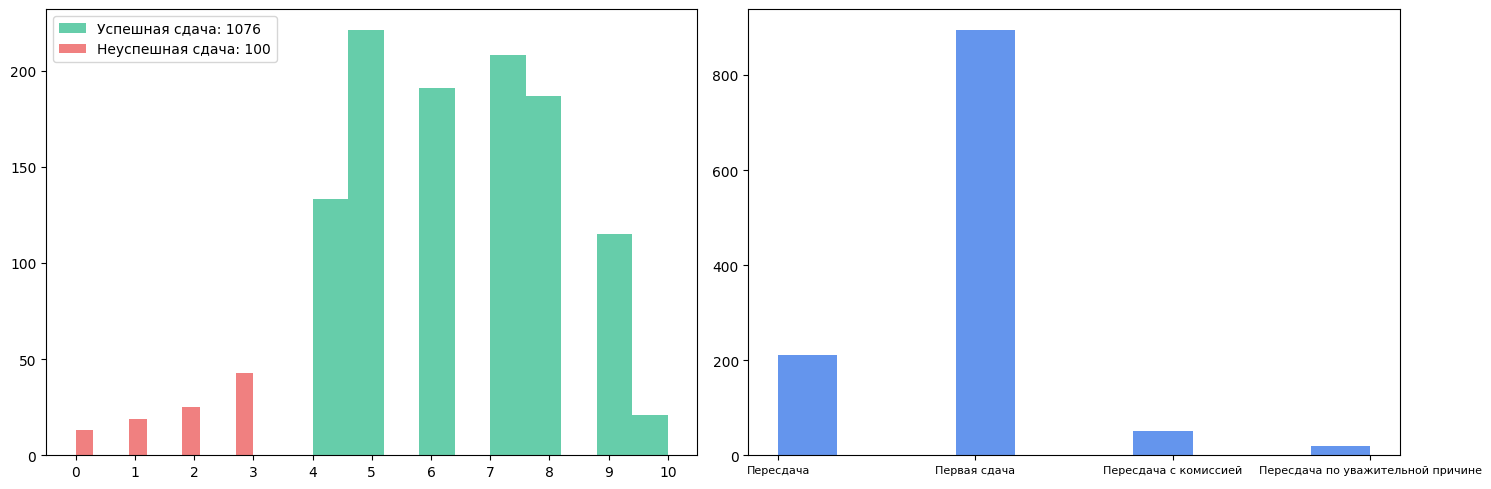

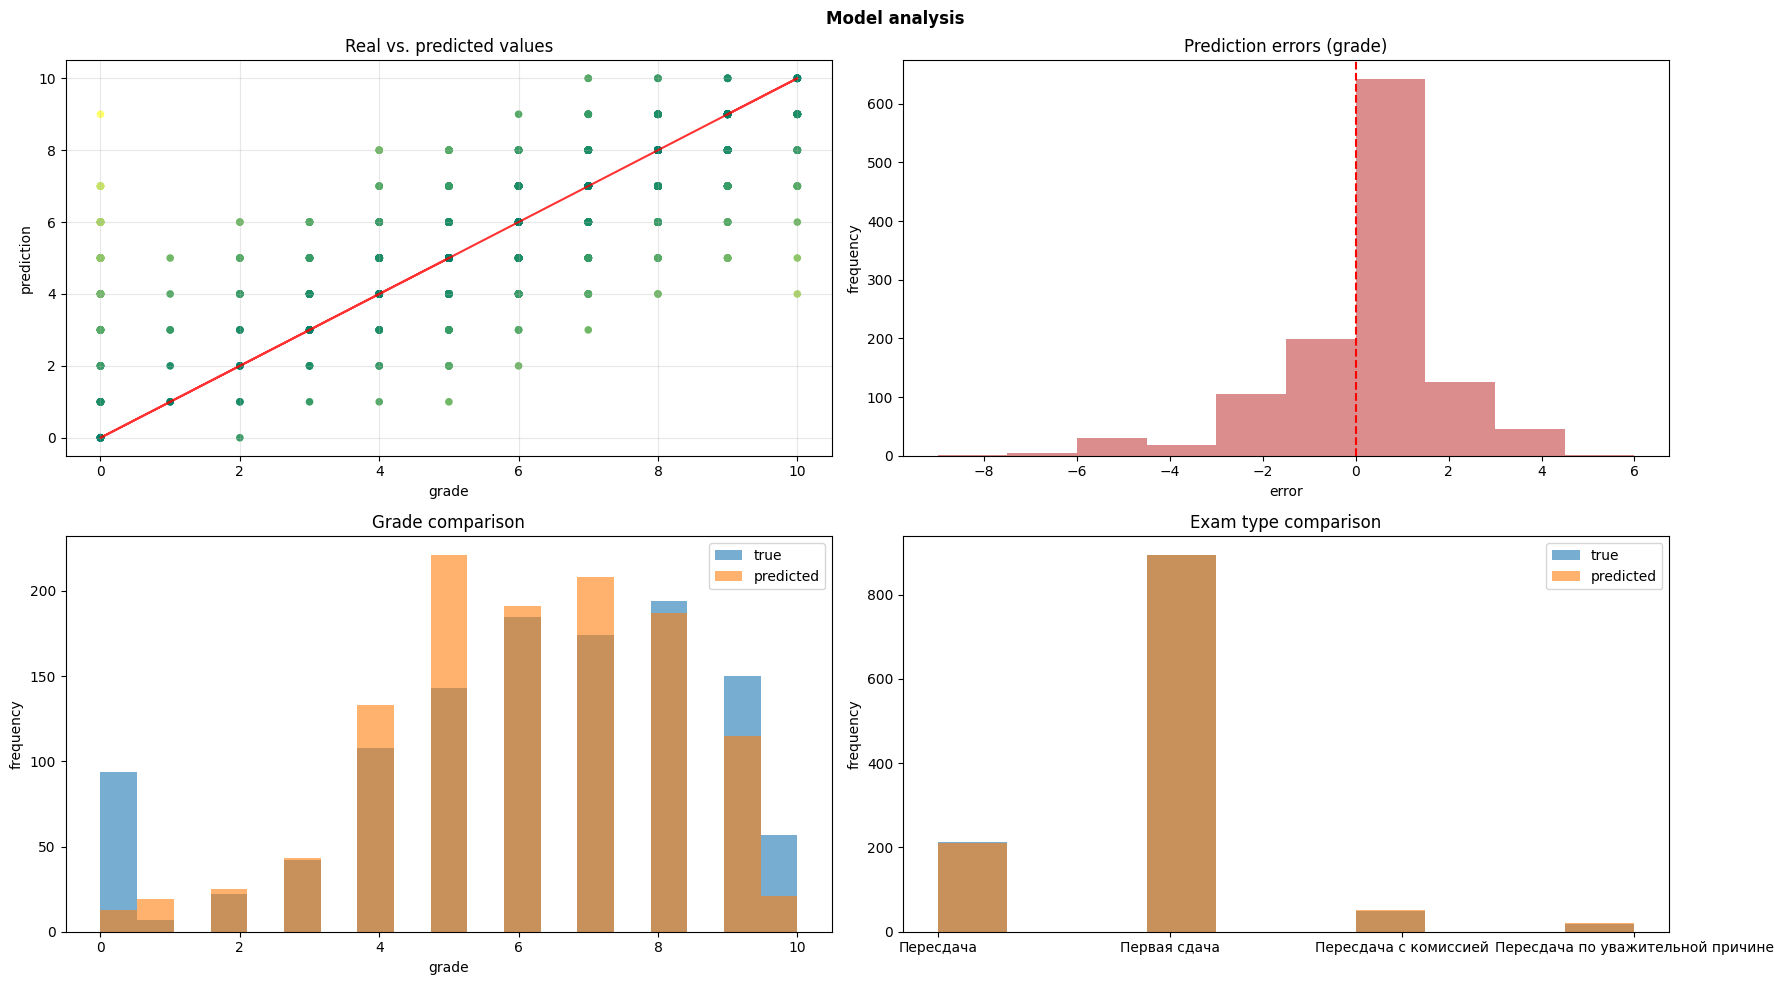

In [7]:
pred_grade, pred_type = model.predict(test_data, fillna = True, visualization = True)
model.analysis(test_data['target_grade'], pred_grade, test_data['target_type'], pred_type)

#### Метрики

In [8]:
mean_absolute_error(pred_grade, test_data['target_grade'])

1.2074829931972788

In [9]:
f1_score(pred_type, test_data['target_type'], average = 'weighted')

0.9616225171804818

In [10]:
model.save("trajectory_model.pkl")

#### Матрица ошибок

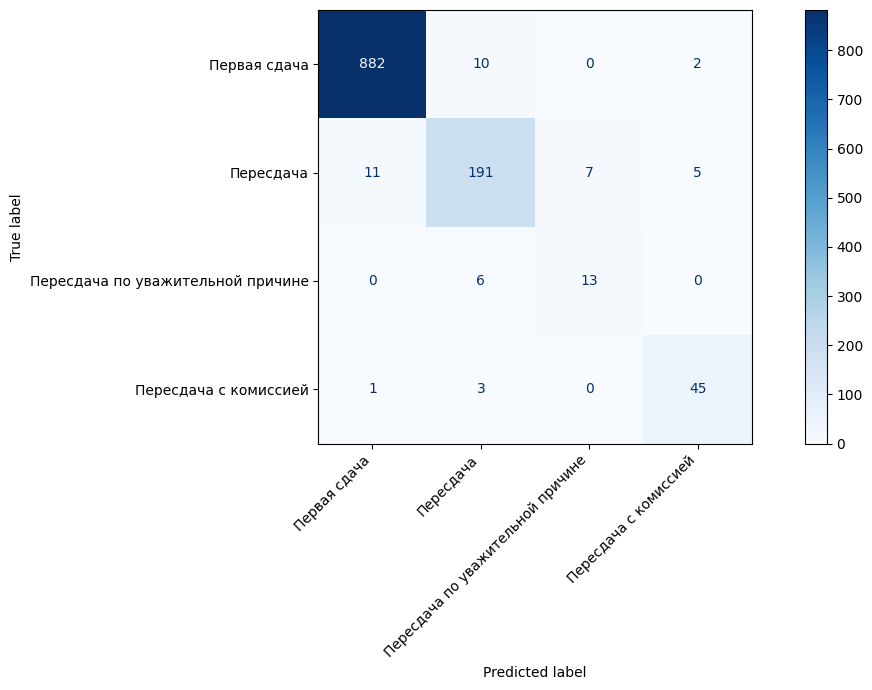

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

ConfusionMatrixDisplay.from_predictions(test_data['target_type'], pred_type, cmap="Blues", ax=ax)

plt.xticks(rotation = 45, ha='right')
plt.tight_layout()
plt.show()